# Edge profiles from TIARA

In [1]:
import imas
import getpass
import numpy as np
from matplotlib.patches import Polygon 
import matplotlib.pyplot as plt
%matplotlib notebook

def get_ggd():
    backend = 12
    database = "ITER"
    shot = 122408
    run = 3
    username = getpass.getuser()
    dbentry = imas.DBEntry(backend, database, shot, run, username)
    status, idx = dbentry.open()
    status = dbentry.get("edge_profiles")
    return status
s = get_ggd()

# Nodes from GGD
nodes = s.grid_ggd[0].space[0].objects_per_dimension[0].object
nVx = len(nodes) # number of nodes
print(f"Number of nodes {nVx}")
vxX = []
vxY = []

for i in range(nVx):
    vxX.append(nodes[i].geometry[0]) # x coordinate
    vxY.append(nodes[i].geometry[1]) # y coordinate

# Faces from GGD
faces = s.grid_ggd[0].space[0].objects_per_dimension[1].object
nFc = len(faces) # number of faces
print(f"Number of faces: {nFc}")

# Cells from GGD
cells = s.grid_ggd[0].space[0].objects_per_dimension[2].object
nCi = len(cells) # number of cells
print(f"Number of cells: {nCi}")

Number of nodes 27247
Number of faces: 80721
Number of cells: 53473


In [2]:
s.grid_ggd[0].space[0].objects_per_dimension[2].object[105-1].boundary[0].neighbours
# nFc = len(faces) # number of faces
# print(f"Number of faces: {nFc}")

array([127,  87, 104], dtype=int32)

In [3]:
# CELLS
# boundary[0] = 
# 		class boundaryObj 
# 		Attribute index: 116 -> face 
# 		Attribute neighbours -> neighbour cell 
# 		[ 6 19  7]

In [4]:
# FACES
# class boundaryObj
# 		Attribute index: 2688 -> point
# 		Attribute neighbours  -> neighbour face
# 		[ 7297  7307  7290  7292  7293  7300  7339 80301  7310 80302 80303  7322
# 		  7358]

## Grid_subset_indentifier_name

In [5]:
grid_subset_indices = dict()
grid_subsets = s.grid_ggd[0].grid_subset    
number_of_grid_subsets = len(grid_subsets)
for i in range(number_of_grid_subsets):
    grid_subset = grid_subsets[i]
    grid_subset_indices[grid_subset.identifier.index] = i
    print(f'{i}: {grid_subset.identifier.index} = {grid_subset.identifier.name}')

0: 1 = nodes
1: 2 = edges
2: 5 = cells
3: 43 = volumes
4: 3 = x_aligned_edges
5: 4 = y_aligned_edges
6: 16 = separatrix
7: -7 = separatrix_X2
8: 15 = core_boundary
9: 26 = core_sol
10: -10 = wall_edges
11: 22 = core
12: 38 = intra_sep
13: 23 = sol
14: 6 = x_points
15: 101 = outer_mid_plane_separatrix
16: 102 = inner_mid_plane_separatrix
17: 103 = outer_target_separatrix
18: 104 = inner_target_separatrix
19: 105 = outer_target_separatrix_2
20: 106 = inner_target_separatrix_2


## grid_subset_edges

In [6]:
edges_subset_indices = set()
edges_subset = s.grid_ggd[0].grid_subset[grid_subset_indices[2]] 
edges_subset_dimension = edges_subset.dimension
edges_subset_elements = edges_subset.element

for i in range(len(edges_subset_elements)):
    if len(edges_subset_elements[i].object):
        edges_subset_indices.add(edges_subset_elements[i].object[0].index)
        
len(edges_subset_indices)
# print(edges_subset_indices)

80721

## grid_subset_cells
All cells (2D) belonging to the associated spaces, implicit declaration

In [7]:
cells_subset_indices = set()
cells_subset = s.grid_ggd[0].grid_subset[grid_subset_indices[5]] 
cells_subset_dimension = cells_subset.dimension
cells_subset_elements = cells_subset.element

for i in range(len(cells_subset_elements)):
    if len(cells_subset_elements[i].object):
        cells_subset_indices.add(cells_subset_elements[i].object[0].index)
        
len(cells_subset_indices)
# print(cells_subset_indices)

53473

## x_aligned_edges
All x-aligned (poloidally) aligned edges belonging to the associated spaces

In [8]:
x_aligned_indices = set()
x_aligned_edges = s.grid_ggd[0].grid_subset[grid_subset_indices[3]] 
x_aligned_edges_dimension = x_aligned_edges.dimension
x_aligned_edges_elements = x_aligned_edges.element

for i in range(len(x_aligned_edges_elements)):
    if len(x_aligned_edges_elements[i].object):
        x_aligned_indices.add(x_aligned_edges_elements[i].object[0].index)
        
# print(x_aligned_indices)        
print(len(x_aligned_indices))

26754


## y_aligned_edges
All y-aligned (radially) aligned edges belonging to the associated spaces

In [9]:
y_aligned_indices = set()
y_aligned_edges = s.grid_ggd[0].grid_subset[grid_subset_indices[4]] 
y_aligned_edges_dimension = y_aligned_edges.dimension
y_aligned_edges_elements = y_aligned_edges.element

for i in range(len(y_aligned_edges_elements)):
    if len(y_aligned_edges_elements[i].object):
        y_aligned_indices.add(y_aligned_edges_elements[i].object[0].index)
        
# print(y_aligned_indices)    
len(y_aligned_indices)

53966

## separatrix
x-aligned edges defining the active separatrix

In [10]:
separatrix_indices = set()
separatrix_edges = s.grid_ggd[0].grid_subset[grid_subset_indices[16]] 
separatrix_edges_dimension = separatrix_edges.dimension
separatrix_edges_elements = separatrix_edges.element

for i in range(len(separatrix_edges_elements)):
    if len(separatrix_edges_elements[i].object):
        separatrix_indices.add(separatrix_edges_elements[i].object[0].index)
        
# separatrix_indices   
len(separatrix_indices)

93

## core_sol
x-aligned edges defining part of active separatrix separating core and sol

In [11]:
core_sol_indices = set()
core_sol_edges = s.grid_ggd[0].grid_subset[grid_subset_indices[26]] 
core_sol_edges_dimension = core_sol_edges.dimension
core_sol_edges_elements = core_sol_edges.element

for i in range(len(core_sol_edges_elements)):
    if len(core_sol_edges_elements[i].object):
        core_sol_indices.add(core_sol_edges_elements[i].object[0].index)
        
# core_sol_indices   
len(core_sol_indices)

31

## wall_edges

In [12]:
wall_indices = set()
wall_edges = s.grid_ggd[0].grid_subset[grid_subset_indices[-10]] 
wall_edges_dimension = wall_edges.dimension
wall_edges_elements = wall_edges.element

for i in range(len(wall_edges_elements)):
    if len(wall_edges_elements[i].object):
        wall_indices.add(wall_edges_elements[i].object[0].index)
        
# wall_indices   
len(wall_indices)

991

##  Core region
Cells inside the active separatrix

In [13]:
core_indices = set()
core_cells = s.grid_ggd[0].grid_subset[grid_subset_indices[22]] 
core_cells_dimension = core_cells.dimension
core_cells_elements = core_cells.element

for i in range(len(core_cells_elements)):
    if len(core_cells_elements[i].object):
        core_indices.add(core_cells_elements[i].object[0].index)

# core_indices
len(core_indices)

989

## Intra_sep region

Cells between the two separatrices

In [14]:
intra_sep_indices = set()
intra_sep_cells = s.grid_ggd[0].grid_subset[grid_subset_indices[38]] 
intra_sep_cells_dimension = intra_sep_cells.dimension
intra_sep_cells_elements = intra_sep_cells.element

for i in range(len(intra_sep_cells_elements)):
    if len(intra_sep_cells_elements[i].object):
        intra_sep_indices.add(intra_sep_cells_elements[i].object[0].index)
        
len(intra_sep_indices)
# intra_sep_indices

10909

## SOL region
Cells defining the main SOL outside of the divertor regions

In [15]:
SOL_indices = set()
SOL_cells = s.grid_ggd[0].grid_subset[grid_subset_indices[23]] 
SOL_cells_dimension = SOL_cells.dimension
SOL_cells_elements = SOL_cells.element

for i in range(len(SOL_cells_elements)):
    if len(SOL_cells_elements[i].object):
        SOL_indices.add(SOL_cells_elements[i].object[0].index)
        
len(SOL_indices)
# SOL_indices

4724

## Implement Tris To Quads

In [16]:
# # Plot of intra_sep region
# fig = plt.figure(figsize=(7, 7)) 
# ax = fig.add_subplot(111, aspect='equal')

# for i in [4725, 4726]:
#     cell_nodes = len(cells[i-1].nodes)
#     cell_points = []
#     for j in range(cell_nodes):
#         index = cells[i-1].nodes[j]-1
#         cell_points.append([vxX[index], vxY[index]])
# #         print(i+1, index, vxX[index], vxY[index])
#     ax.add_patch(Polygon(cell_points, closed=True,fill=False)) 

# ax.set_xlim((min(vxX)-0.1, max(vxX)+0.1)) 
# ax.set_ylim((min(vxY)-0.1, max(vxY)+0.1))
# plt.xlabel('R [m]')
# plt.ylabel('Z [m]')
# plt.title('intra_sep region')
# # plt.savefig('slika.SVG')
# plt.show()

In [17]:
# Cells
s.grid_ggd[0].space[0].objects_per_dimension[2].object[4725-1].boundary[1].neighbours


array([4726, 4727, 4728], dtype=int32)

In [18]:
# Faces
s.grid_ggd[0].space[0].objects_per_dimension[1].object[7299-1].boundary[1].neighbours

array([ 7297,  7307,  7290,  7292,  7293,  7300,  7339,  7310, 80433,
       80434, 80435,  7322,  7358], dtype=int32)

In [19]:
# Nodes
# s.grid_ggd[0].space[0].objects_per_dimension[0].object[0]

In [20]:
# for i in range(nCi):
#     cell_nodes = len(cells[i].nodes)
#     cell_points = []
#     for j in range(cell_nodes):
#         index = cells[i].nodes[j] - 1
#         cell_points.append([vxX[index], vxY[index]])
# #         print(i+1, index, vxX[index], vxY[index])
# #         print(sorted(cell_points))

In [21]:
# fig = plt.figure(figsize=(7, 7)) 
# ax1 = fig.add_subplot(111, aspect='equal')

# for i in range(nCi):
#     cell_nodes = len(cells[i].nodes)
#     cell_points = []
#     for j in range(cell_nodes):
#         index = cells[i].nodes[j] - 1
#         cell_points.append([vxX[index], vxY[index]])
#     ax1.add_patch(Polygon(cell_points, closed=True, fill=False))
    
# ax1.set_xlim((min(vxX) - 0.1, max(vxX) + 0.1)) 
# ax1.set_ylim((min(vxY) - 0.1, max(vxY) + 0.1))
# ax1.set_xlabel('R [m]')
# ax1.set_ylabel('Z [m]')
# plt.show()

# Geometry

<IPython.core.display.Javascript object>


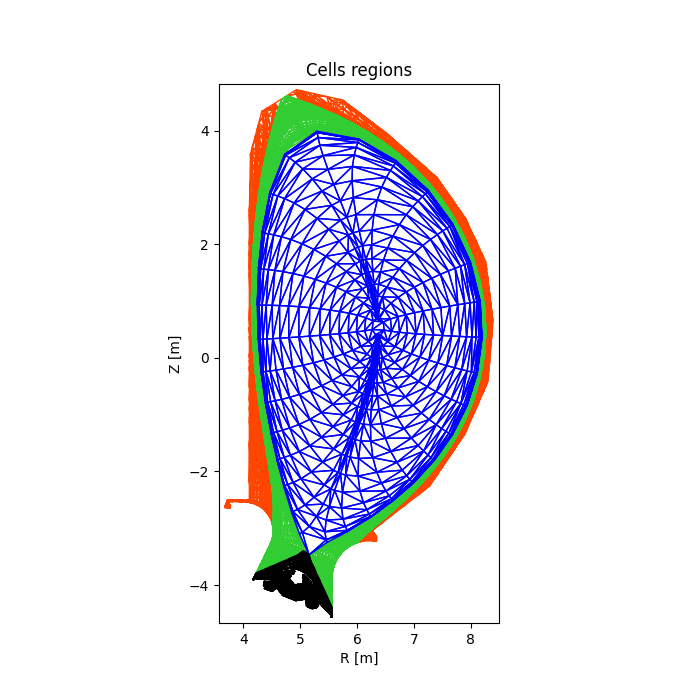

In [22]:
# Plot of cells regions
fig = plt.figure(figsize=(7, 7)) 
ax = fig.add_subplot(111, aspect='equal')

# Defining private region by subtracting all cells from other regions
private_region = cells_subset_indices.difference(core_indices, intra_sep_indices, SOL_indices)

regions = [
    (SOL_indices, 'orangered'),        # SOL region
    (intra_sep_indices, 'limegreen'),  # Intra_sep region
    (core_indices, 'blue'),            # Core region
    (private_region, 'black')          # Private region
]

for indices, edge_color in regions:
    for i in indices:
        cell_nodes = len(cells[i-1].nodes)
        cell_points = []
        for j in range(cell_nodes):
            index = cells[i-1].nodes[j] - 1
            cell_points.append([vxX[index], vxY[index]])
        ax.add_patch(Polygon(cell_points, closed=True, fill=False, edgecolor=edge_color))

ax.set_xlim((min(vxX) - 0.1, max(vxX) + 0.1)) 
ax.set_ylim((min(vxY) - 0.1, max(vxY) + 0.1))
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.title('Cells regions')
plt.show()

<IPython.core.display.Javascript object>


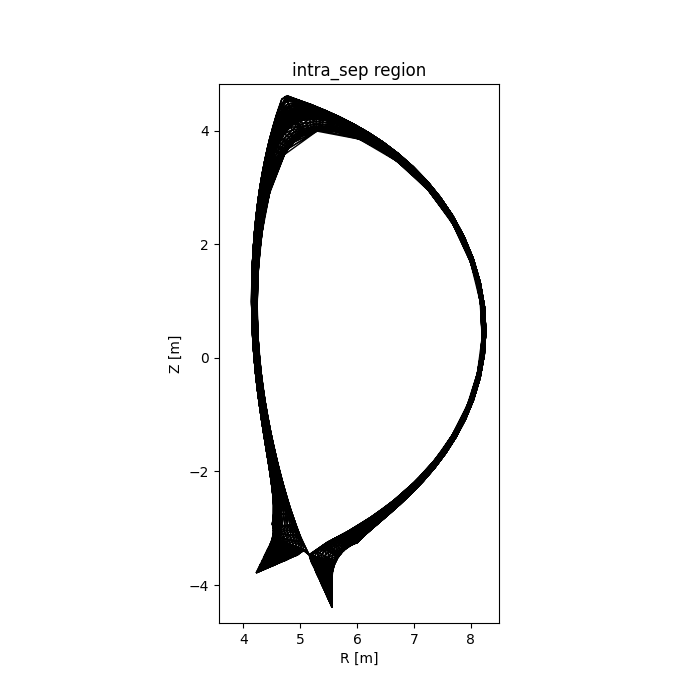

In [23]:
# Plot of intra_sep region
fig = plt.figure(figsize=(7, 7)) 
ax = fig.add_subplot(111, aspect='equal')

for i in set(intra_sep_indices):
    cell_nodes = len(cells[i-1].nodes)
    cell_points = []
    for j in range(cell_nodes):
        index = cells[i-1].nodes[j]-1
        cell_points.append([vxX[index], vxY[index]])
#         print(i+1, index, vxX[index], vxY[index])
    ax.add_patch(Polygon(cell_points, closed=True,fill=False)) 

ax.set_xlim((min(vxX)-0.1, max(vxX)+0.1)) 
ax.set_ylim((min(vxY)-0.1, max(vxY)+0.1))
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.title('intra_sep region')
# plt.savefig('intra_sep region.PNG')
plt.show()

In [24]:
# x_aligned_indices.isdisjoint(y_aligned_indices)

<IPython.core.display.Javascript object>


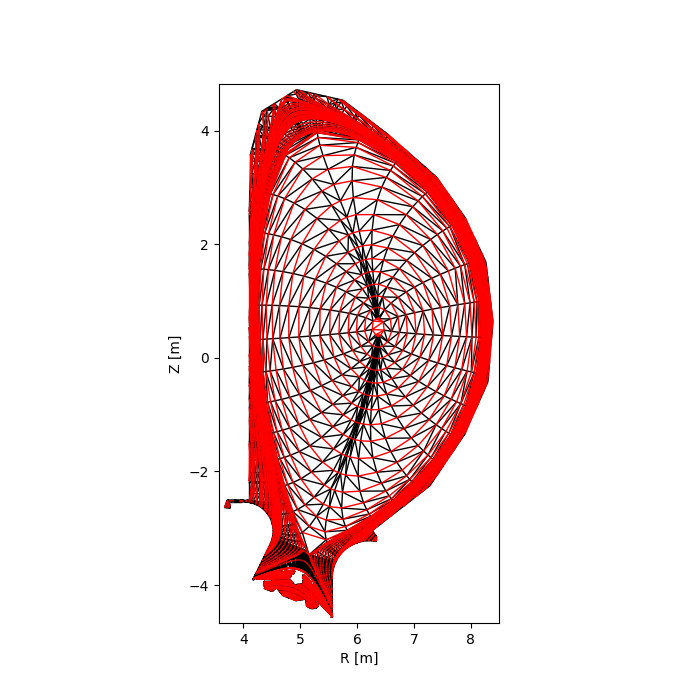

In [25]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, aspect='equal')

# intra_sep_indices_x_aligned = intra_sep_indices.intersection(x_aligned_indices)
# intra_sep_indices_y_aligned = intra_sep_indices.intersection(y_aligned_indices)

for i in set(y_aligned_indices):
    fcVx_first_point = faces[i-1].nodes[0] - 1
    fcVx_second_point = faces[i-1].nodes[1] - 1

    first_point = [vxX[fcVx_first_point], vxY[fcVx_first_point]]
    second_point = [vxX[fcVx_second_point], vxY[fcVx_second_point]]
    face_points = np.array([first_point, second_point])

    ax.add_patch(Polygon(face_points, closed=False, fill=False))

for i in set(x_aligned_indices):
    fcVx_first_point = faces[i-1].nodes[0] - 1
    fcVx_second_point = faces[i-1].nodes[1] - 1

    first_point = [vxX[fcVx_first_point], vxY[fcVx_first_point]]
    second_point = [vxX[fcVx_second_point], vxY[fcVx_second_point]]
    face_points = np.array([first_point, second_point])

    ax.add_patch(Polygon(face_points, closed=False, fill=False, edgecolor='red'))

ax.set_xlim((min(vxX)-0.1, max(vxX)+0.1))
ax.set_ylim((min(vxY)-0.1, max(vxY)+0.1))
ax.set_xlabel('R [m]')
ax.set_ylabel('Z [m]')
ax.set_title('')
plt.show()

<IPython.core.display.Javascript object>


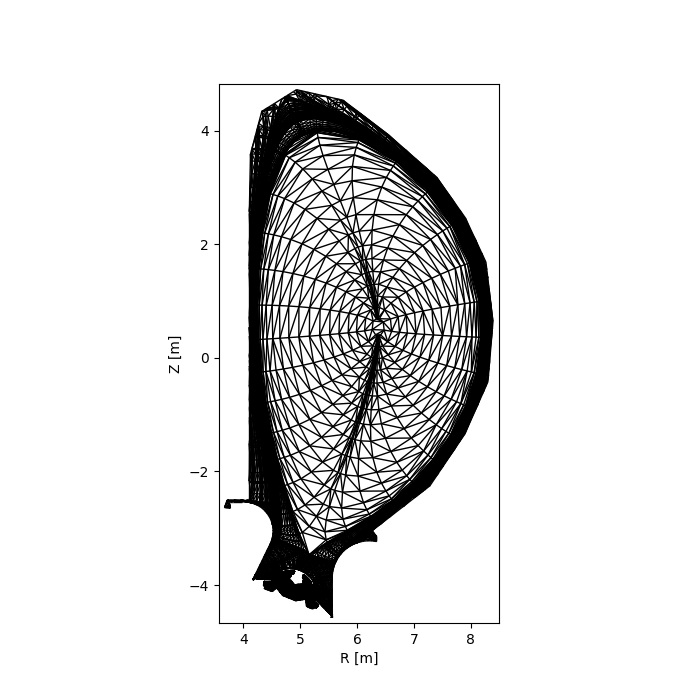

In [28]:
# Plot of faces

fig = plt.figure(figsize=(7, 7)) 
ax = fig.add_subplot(111, aspect='equal')

for i in range(nFc):
#     if fcAligned[i] == 1:
        fcVx_first_point = faces[i-1].nodes[0] - 1
        fcVx_second_point = faces[i-1].nodes[1] - 1

        first_point = [vxX[fcVx_first_point], vxY[fcVx_first_point]]
        second_point = [vxX[fcVx_second_point], vxY[fcVx_second_point]]
        face_points = np.array([first_point, second_point])
#         print(i, face_points)
        ax.add_patch(Polygon(face_points, closed=False, fill=False))

ax.set_xlim((min(vxX)-0.1, max(vxX)+0.1))
ax.set_ylim((min(vxY)-0.1, max(vxY)+0.1))
ax.set_xlabel('R [m]')
ax.set_ylabel('Z [m]')
ax.set_title('')
plt.show()

<IPython.core.display.Javascript object>


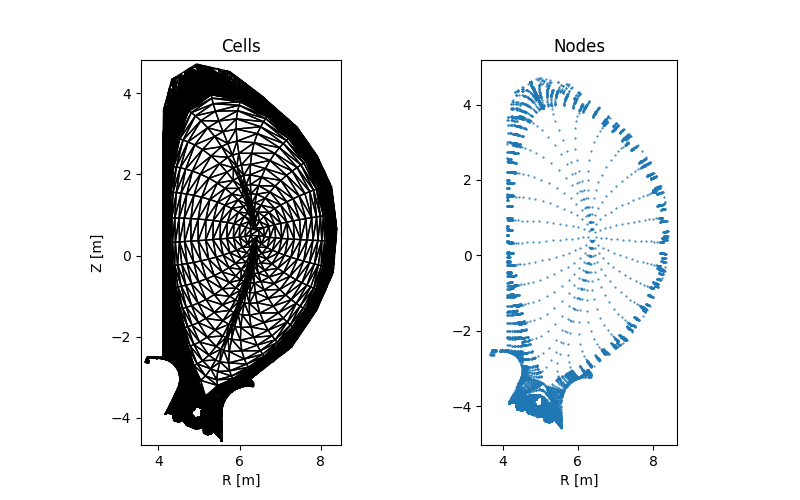

In [27]:
# Plot of cells and nodes
fig = plt.figure(figsize=(8, 5)) 
ax1 = fig.add_subplot(121, aspect='equal')

for i in range(nCi):
    cell_nodes = len(cells[i-1].nodes)
    cell_points = []
    for j in range(cell_nodes):
        index = cells[i-1].nodes[j] - 1
        cell_points.append([vxX[index], vxY[index]])
    ax1.add_patch(Polygon(cell_points, closed=True, fill=False))
    
ax1.set_xlim((min(vxX) - 0.1, max(vxX) + 0.1)) 
ax1.set_ylim((min(vxY) - 0.1, max(vxY) + 0.1))
ax1.set_xlabel('R [m]')
ax1.set_ylabel('Z [m]')
ax1.set_title('Cells')

ax2 = fig.add_subplot(122, aspect='equal')
ax2.plot(vxX, vxY, '.', markersize=1)
ax2.set_xlabel('R [m]')
ax2.set_title('Nodes')

plt.show()